In [49]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [50]:
using Revise
using Newtrinos
using Newtrinos.osc

In [241]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 25.0, r = 1.0), (m₀ = Uniform{Float64}(a=0.001, b=2.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#50"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(OscillationConf

In [242]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [243]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [244]:
p = Newtrinos.get_params(experiments)

(N = 25.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [245]:
using Setfield

In [246]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 25.0, m₀ = 0.13150709772441188, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [247]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [248]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 58671.61974231792
 61373.29504779364
 56399.87719515655
 69511.35779160396
 77540.83111680084
 86270.27438518628
 87151.38385751541
 82448.3490642876
 78255.14658258526
 73034.4790375597
 65989.06537901779
 59628.88178276927
 53618.54676565998
 48945.94369648877
 44428.6231215148
 39728.52330445951
 33374.81316376956
 34424.05727868475
 25202.260400341398
 19739.52855151699
 14649.970926576681
  9837.217585630064
  6379.149801387837
  6728.625356722334
  3675.7033582100644
 17160.152695249726

In [249]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 58713.88076126539
 61344.17916173377
 56496.538453429195
 69327.65216765192
 77418.85218650823
 86598.7081833538
 87000.29699536506
 82543.05776992344
 78179.53604051095
 72901.93893304735
 66090.76200297245
 59655.09670013735
 53630.04628863667
 48801.775514139765
 44519.61942597658
 39805.716630860254
 33426.79565160906
 34344.950760160835
 25176.252150164677
 19734.618791548935
 14609.640986576305
  9853.774996131731
  6407.297303341568
  6712.878127439337
  3677.1339637249325
 17136.367084357677

In [250]:
using CairoMakie

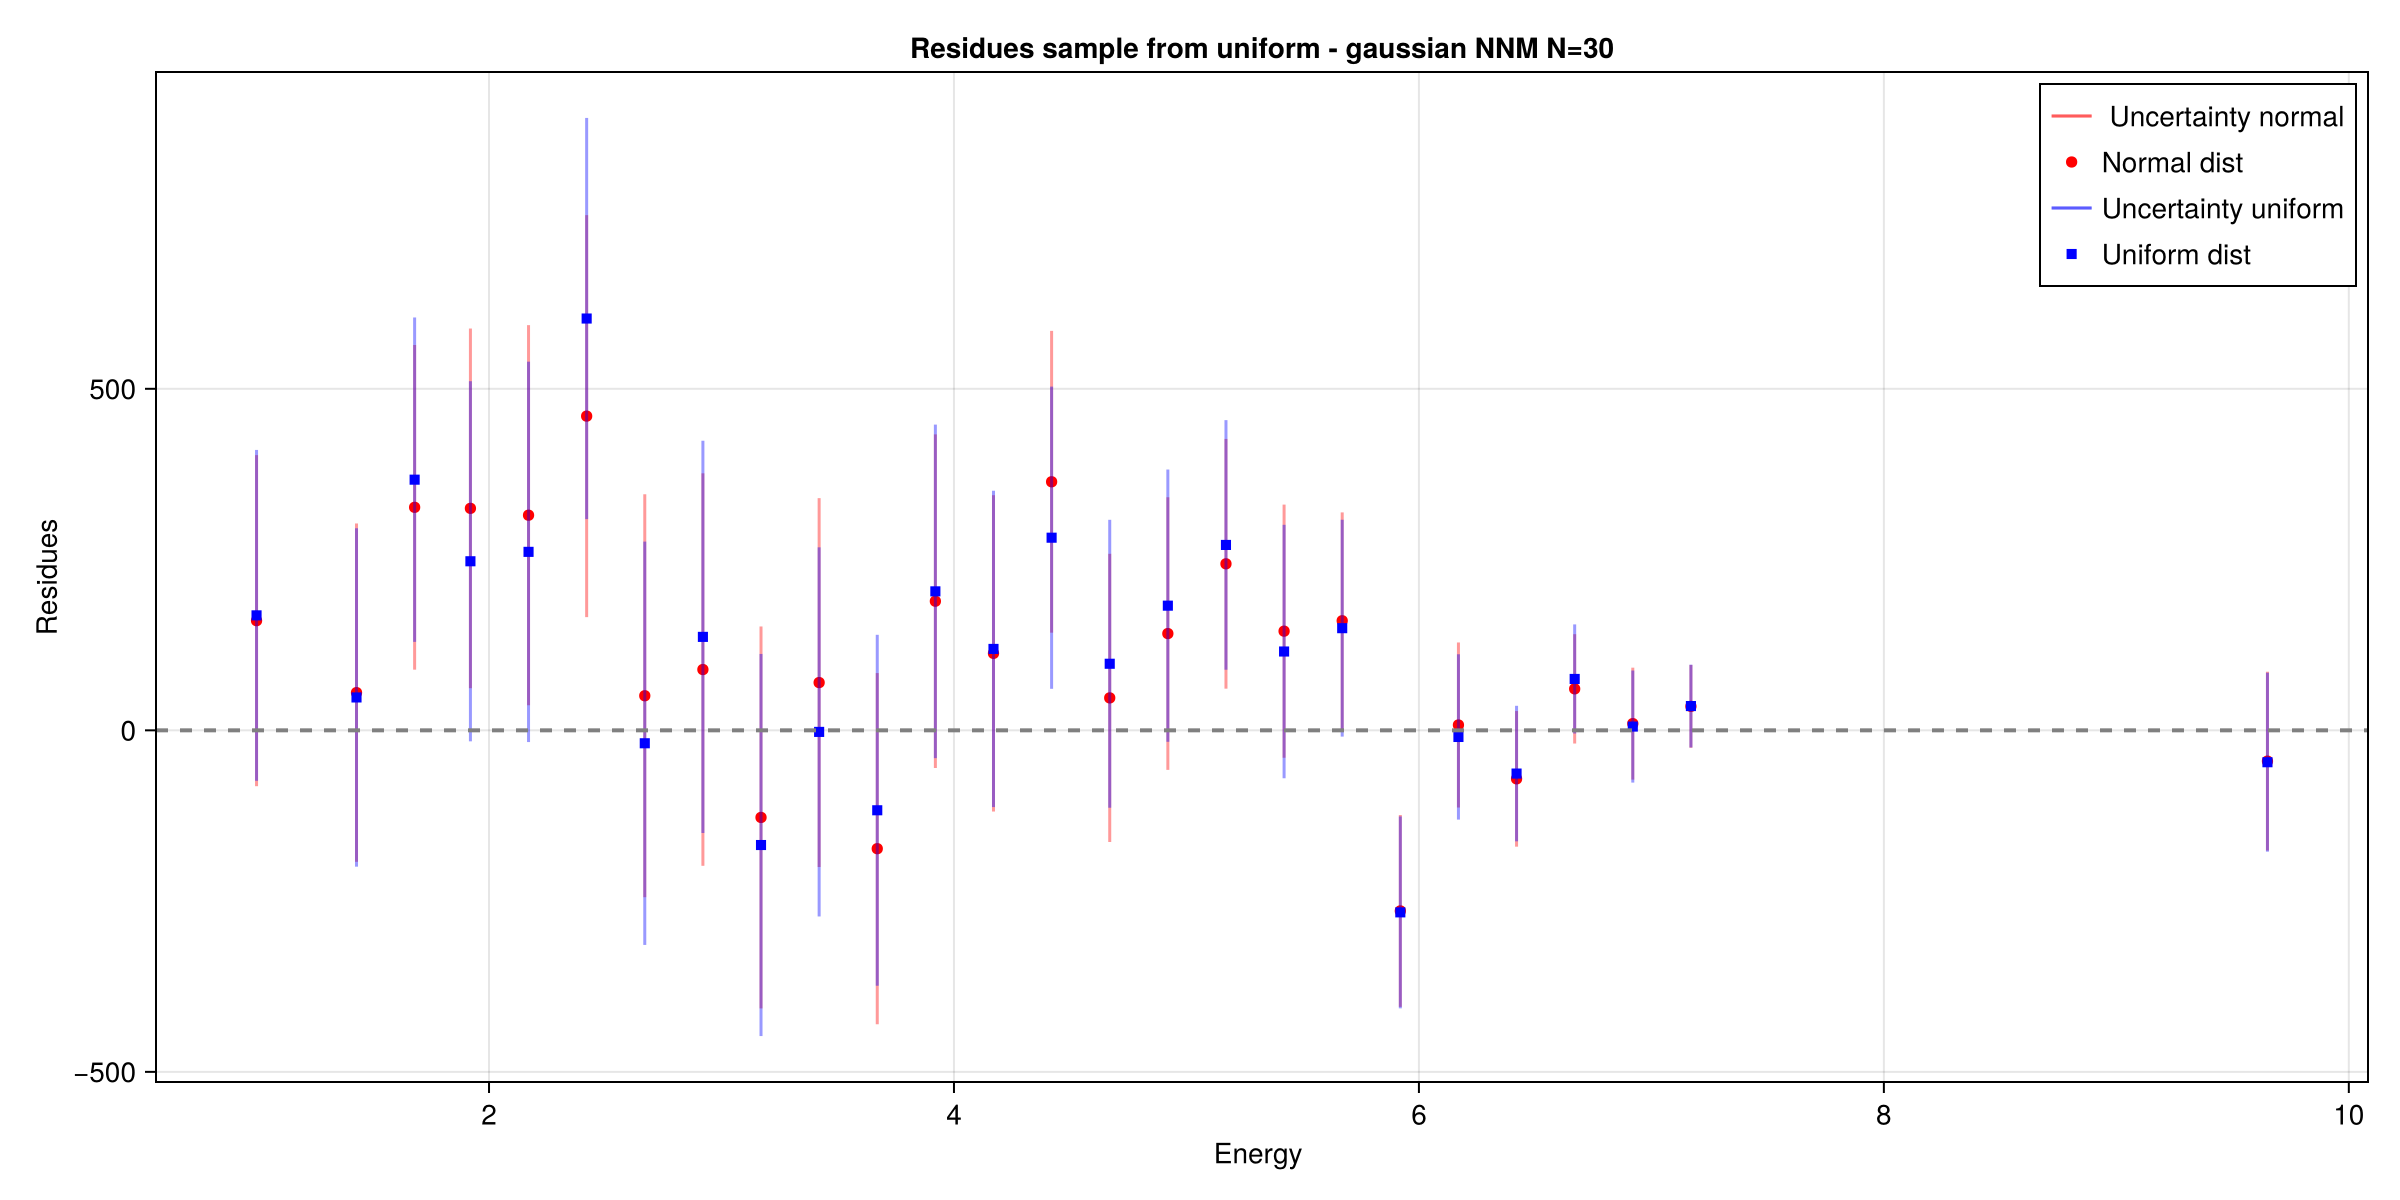

CairoMakie.Screen{IMAGE}


In [251]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=30")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [252]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [253]:

using ProgressMeter
using MeasureBase

In [254]:
function random_sampling(physics, experiments, p)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/1000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*(1+2/p.r))) 
      new_m₀_norm=rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*(1+2/p.r)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm

      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

      #chi_squared_un = sum((observed.- expected_un).^2 ./ expected_un_var)
      #chi_squared_norm = sum((observed.- expected_norm).^2 ./ expected_norm_var)
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [255]:
trial=random_sampling(physics, experiments, p)

Progress: 100%|█████████████████████████████████████████| Time: 0:04:29


([-169.94403117926436, -169.15814633219838, -169.20017472120546, -169.46700439682257, -169.96418962182264, -169.6993378966613, -169.60068203547476, -168.99581030945495, -168.77430106288435, -169.31660391603526  …  -170.01560490878578, -169.0628823848053, -169.64985445113953, -169.2763074623319, -168.8921996653667, -169.83280610562292, -169.05252524547743, -170.5604555462455, -170.05678169060806, -170.37343367516286], [-169.55791545920565, -169.2588683489884, -170.05006490717344, -169.8344143483317, -169.176516647809, -169.95386661525544, -169.2553446700563, -169.83506230245564, -169.4435155470588, -169.96983382842555  …  -169.464023320529, -169.3077381375255, -169.24673021273227, -169.7054413834617, -169.4582836456158, -169.0424657989458, -169.0602459873316, -169.53781790371497, -169.51329952762703, -169.5819408838194])

In [256]:
trial=.-trial # to have the negative log likelihood

([169.94403117926436, 169.15814633219838, 169.20017472120546, 169.46700439682257, 169.96418962182264, 169.6993378966613, 169.60068203547476, 168.99581030945495, 168.77430106288435, 169.31660391603526  …  170.01560490878578, 169.0628823848053, 169.64985445113953, 169.2763074623319, 168.8921996653667, 169.83280610562292, 169.05252524547743, 170.5604555462455, 170.05678169060806, 170.37343367516286], [169.55791545920565, 169.2588683489884, 170.05006490717344, 169.8344143483317, 169.176516647809, 169.95386661525544, 169.2553446700563, 169.83506230245564, 169.4435155470588, 169.96983382842555  …  169.464023320529, 169.3077381375255, 169.24673021273227, 169.7054413834617, 169.4582836456158, 169.0424657989458, 169.0602459873316, 169.53781790371497, 169.51329952762703, 169.5819408838194])

In [257]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

169.49624453330472

In [258]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  dayabay= Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

likelihood_SM=-logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

[ Info: Loading dayabay data


168.90003273508322

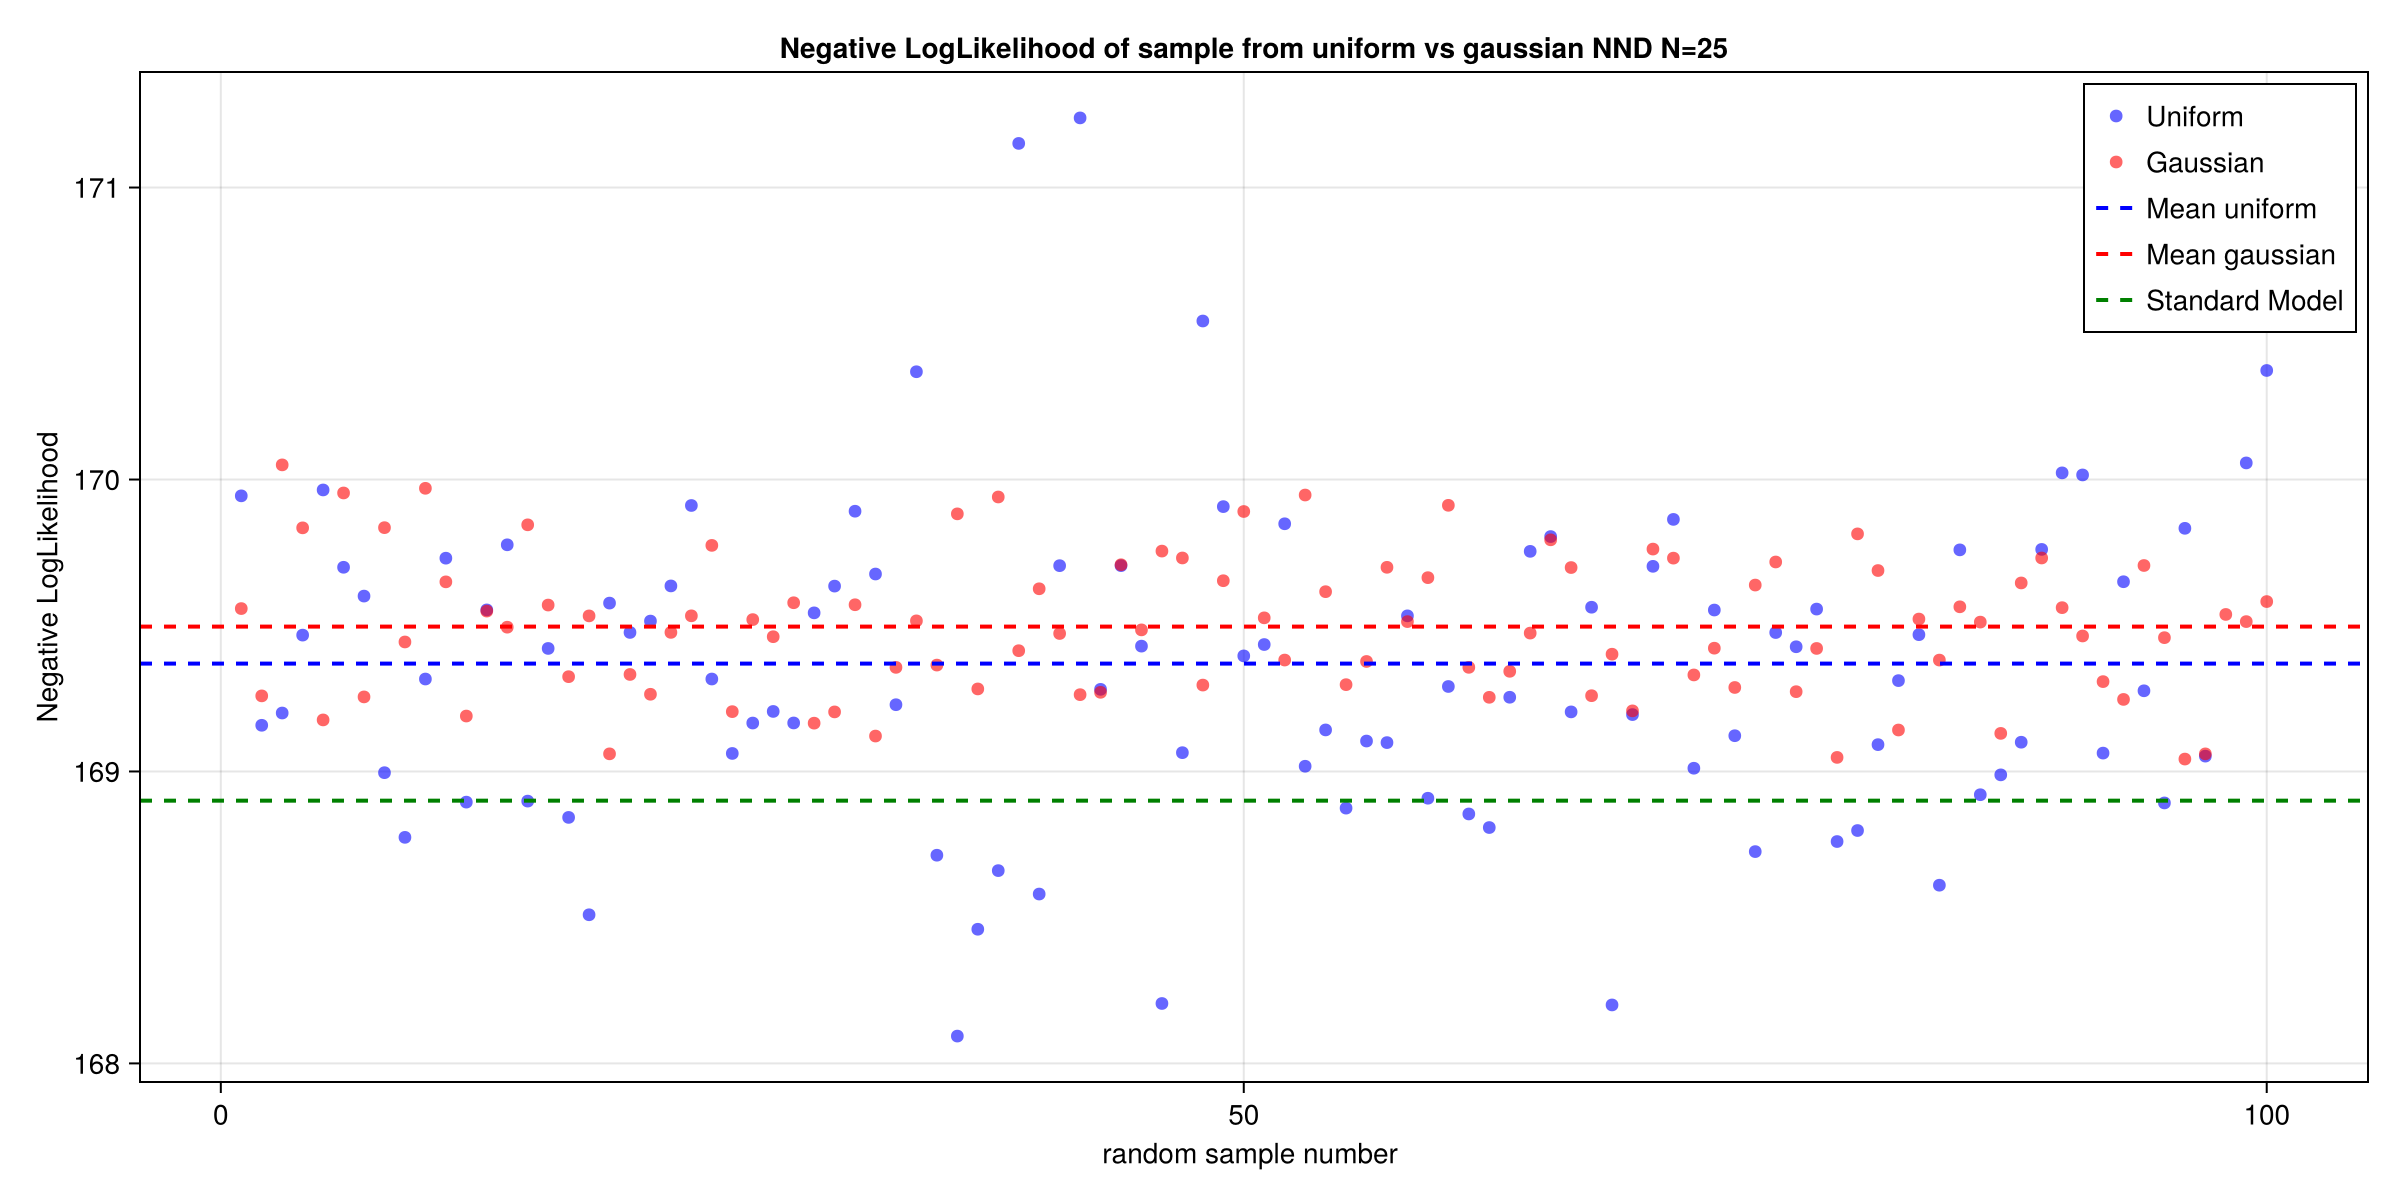

In [259]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NND N=25")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_samples_NND_N25_m0=0.1.png", fig)

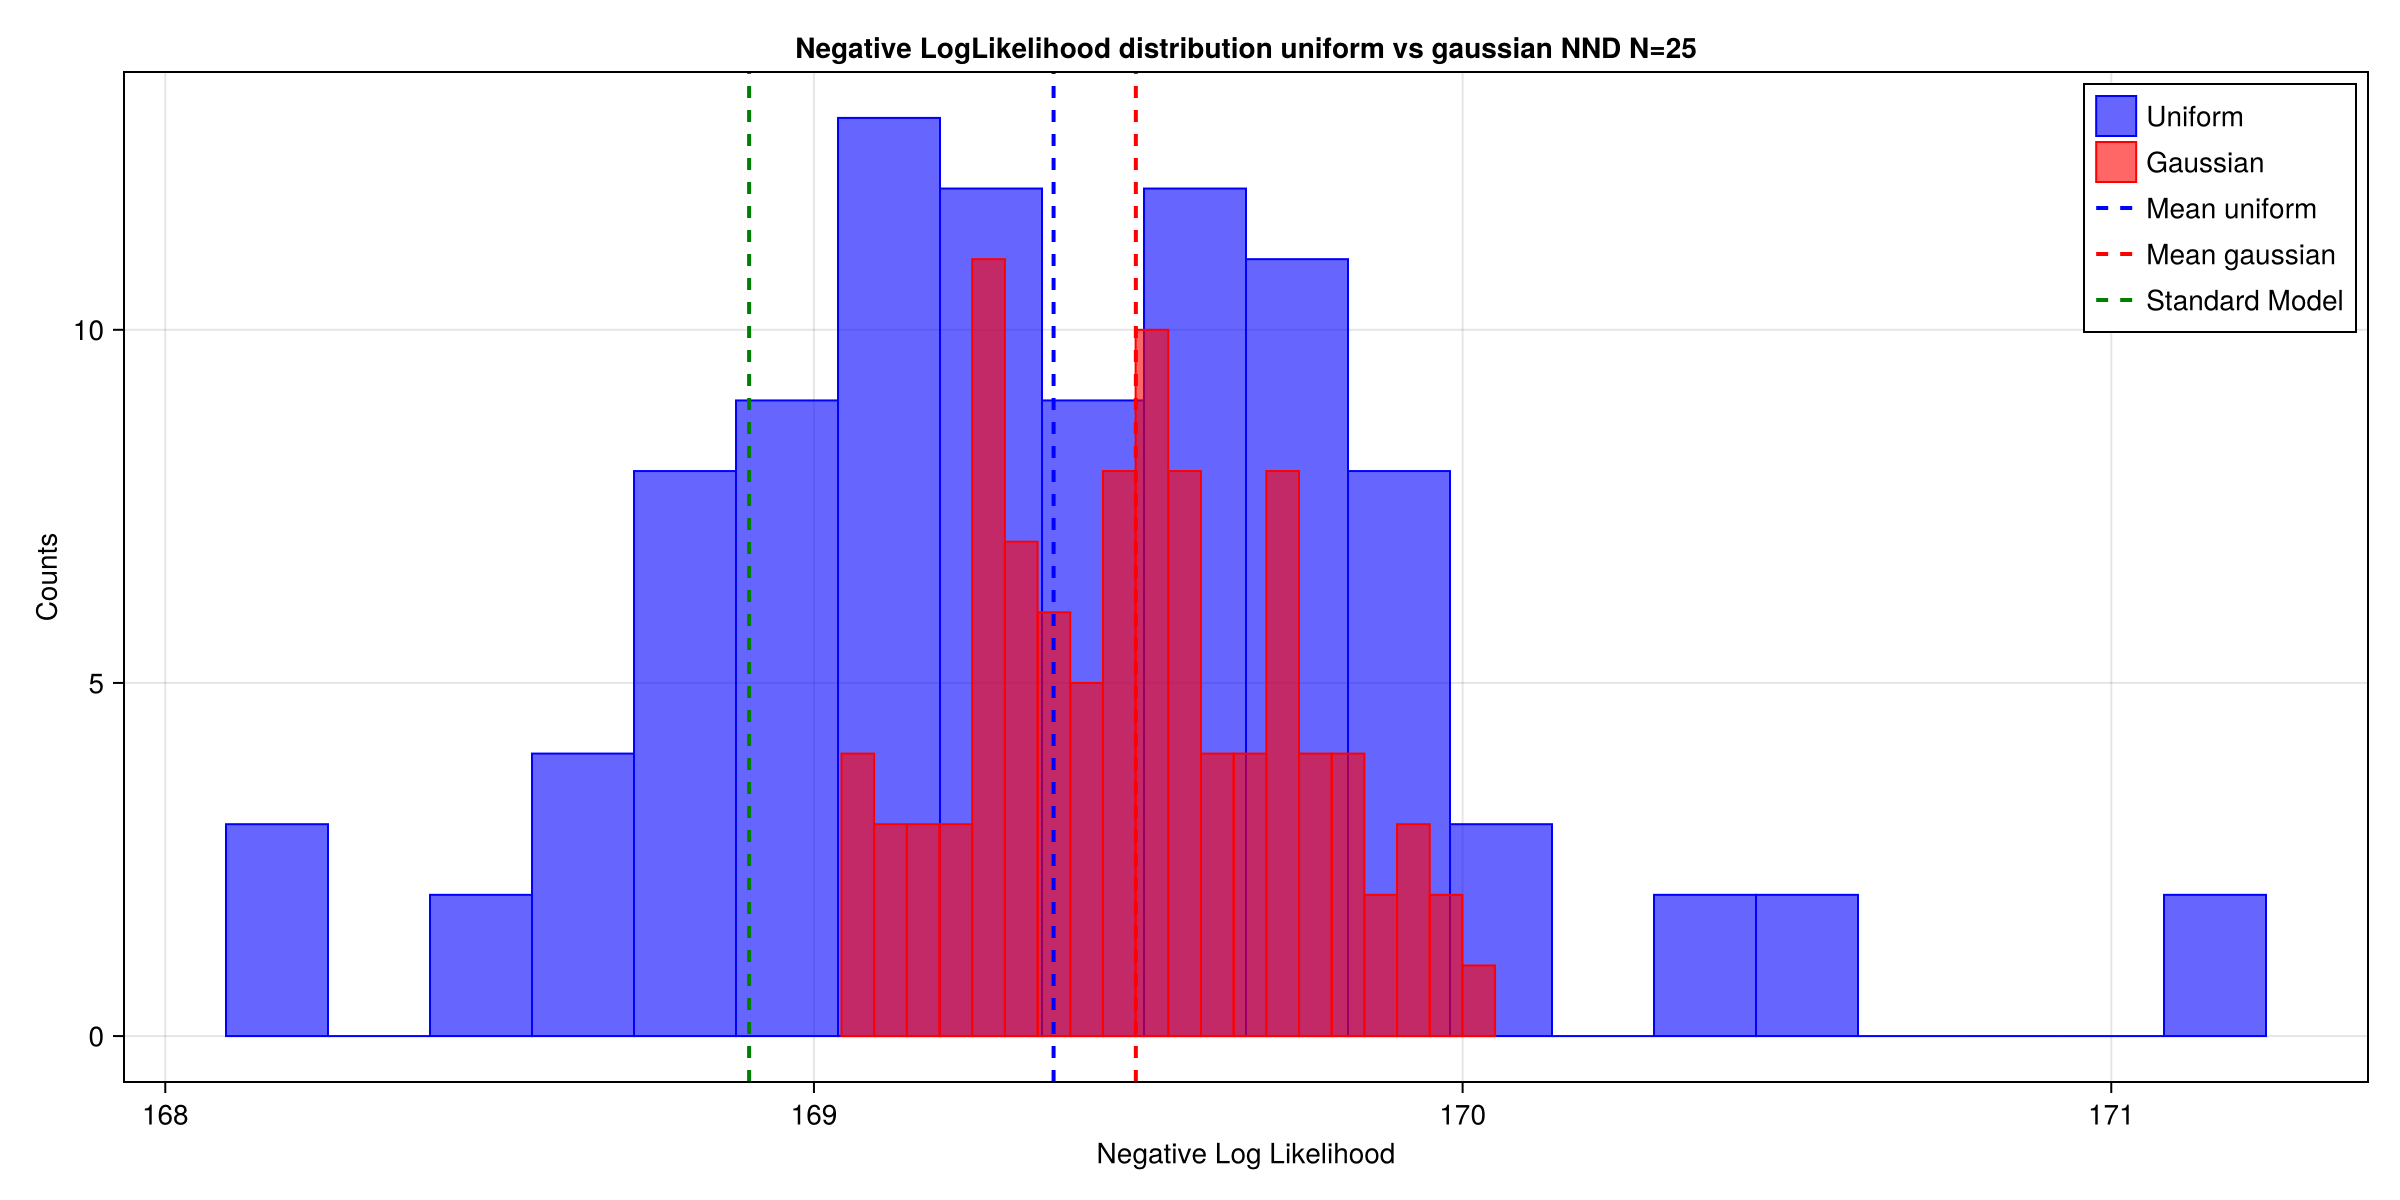

In [260]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NND N=25")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NND_N25_m0=0.1.png", fig)